# Лабораторна робота 1. Шифр Вiженера. Частотний криптоаналiз

## Л1.1 Побудуйте гiстограму частот появи лiтер в текстi.

In [1]:
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
text = "Мова кожного народу ґ — явище давнє, її коріння сягає у доісторичні часи. Вона є найгеніальнішим результатом матеріальної і духовної діяльності багатьох поколінь. Кожне створене слово — це символ сформованої ідеї, це відображення намагань людини проникнути у світ природи, у саму себе. Національна мова — це здобуток культури, духовної діяльності певного народу. Це одночасно здобуток культури всього людства. Адже кожна мова доповнює іншу, а разом вони - витвір світового розуму. Мова й пісня — дві найважливіші фортеці. Їх народ повинен оберігати пильніше і відчайдушніше, ніж свої кордони. Навіть втрачені кордони з часом можна відновити, а мову відродити майже неможливо. Мова — це скарб, який важко оцінювати. Мову не можна замінити чужою, бо це означало б, що народу потрібно прищепити чуже серце, вселити чужу душу. Навертати, схиляти до чужої мови, силою примушувати народ зрікатися рідної мови — це найбільший злочин."

In [3]:
text = text.lower() 

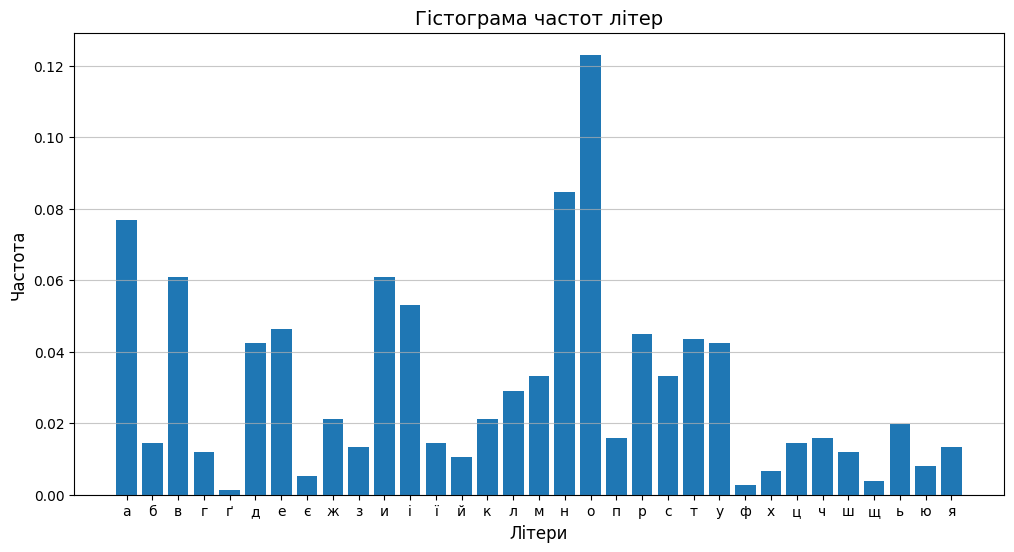

In [4]:
alphabet = "абвгґдеєжзиіїйклмнопрстуфхцчшщьюя"
final_text = ''.join([c for c in text if c in alphabet])

counts = Counter(final_text)
length = len(final_text)
frequencies = {}
for i in alphabet:
    frequencies[i] = counts[i] / length

ukr_frequencies = frequencies
plt.figure(figsize=(12, 6))
plt.bar(frequencies.keys(), frequencies.values())
plt.title("Гістограма частот літер", fontsize=14)
plt.xlabel("Літери", fontsize=12)
plt.ylabel("Частота", fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.show()

## Л1.2 Реалiзуйте алгоритм шифрування Вiженера.

In [5]:
N = len(alphabet)

def vigenere_encrypt(text, key):
    text = text.lower()
    text = ''.join([c for c in text if c in alphabet])
    key = key.lower()
    full_key = (key + text)[:len(text)]
    res = ""
    for i in range(len(text)):
        letter_index = alphabet.find(text[i])
        key_index = alphabet.find(full_key[i])
        res += alphabet[(letter_index + key_index) % N]
    return res

def vigenere_decrypt(ciphertext, key):
    key = key.lower()
    ciphertext = ciphertext.lower()
    ciphertext = ''.join([c for c in ciphertext if c in alphabet])
    full_key = list(key)
    res = ""
    for i in range(len(ciphertext)):
        cipherletter_index = alphabet.find(ciphertext[i])
        key_index = alphabet.find(full_key[i])
        letter_index = (cipherletter_index - key_index + N) % N
        letter = alphabet[letter_index]
        res += letter
        full_key.append(letter)
    return res

open_text = "білі мухи налетіли"
key = "зима"

ciphertext = vigenere_encrypt(open_text, key)
print("Зашифрований текст:", ciphertext)
print("Розшифрований текст:", vigenere_decrypt(ciphertext, key))

Зашифрований текст: исюінбєсауємеіьм
Розшифрований текст: білімухиналетіли


## Л1.3 Проведiть криптоаналiз шифру Вiженера i розшифруйте запропонований крипто-текст, не знаючи секретного ключа.

### Криптоаналiз шифру Вiженера складається з двох частин: визначення довжини ключа та визначення ключа для знайденої довжини.

In [6]:
text = "Золочівський замок вражає оригінальністю архітектурного ансамблю. Замість суворих мурів його оборонний комплекс складають широкі земельні вали – бастіони голландського типу. Саме вони за часів розвитку артилерії були найкращими захисниками від гарматних ядер. Їх спланували в такий спосіб, що навіть коли ворог захоплював один із бастіонів, то обстріл тривав із сусідніх. Чудовий земляний захисток закінчується равеліном – насипом перед брамою замку."
key_true = "криптографія"
ciphertext_3 = vigenere_encrypt(text, key_true)
print("Зашифрований текст:", ciphertext_3)

Зашифрований текст: удхґмщджьдсїооюгжйтсдкнющипщюввьхішєоиугштсіебжемгдхшиеьудоцопщсеосегаопхябжаябждгдіигжґшїцясбґмфбедюхйпокжїбфжешцзімґґчїстощсиеґшцлбсдоьхбнцижявйсєхбуддґгмгршюийузіоцрчпрюкнажаївфщйтуґдиґтущцрєтнафизибюькщццїрдшижаигнцвбміуїїґпґнчлбдськксахйдзрсціюєнкїфимяеціюгґодрттяґьжґотгжпнгчрлпфірвмїещчвсизтаеюїфорїьиияцчґсччхмчуабріацфіаочввуьшбщжнффцчлнипейщамнядєхдксрьпртбнґфсорсцґмхптбщ


### Визначення довжини ключа на основі Index of Coincidence.

**Індекс збігів ($IC$)** - показує наскiльки часто двi лiтери в текстi спiвпадають та обчислюється за формулою:
$$IC = c \cdot \frac{\sum_{i=А}^{Я} N_i(N_i - 1)}{N(N - 1)}$$

* **$N$** — довжина тексту;
* $N_А, N_Б, \dots, N_Я$ - кiлькiсть вiдповiдних лiтер;
* **$c$** — нормуючий коефіцієнт (для української абетки $c = 33$).

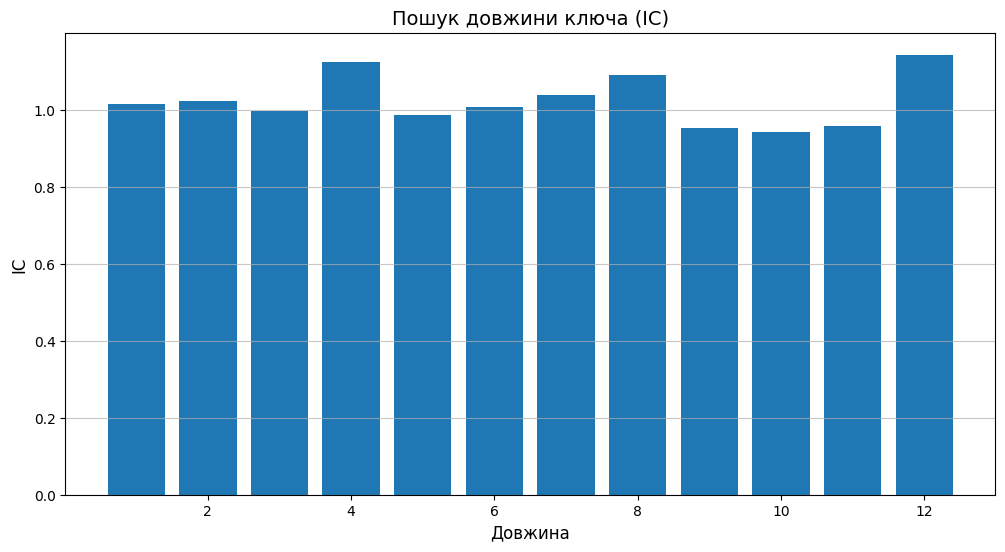

In [7]:
с = 33

def calculate_ic(text):
    n = len(text)  
    frequencies = {}
    for i in text:
        frequencies[i] = frequencies.get(i, 0) + 1
    
    sum_part = sum(n_i * (n_i - 1) for n_i in frequencies.values())
    ic = с * sum_part / (n * (n - 1))
    return ic

diag_ic = {}
for r in range(1, 13):
    current_ics = []
    for i in range(r):
        group = ciphertext_3[i::r] 
        if len(group) > 1: 
            current_ics.append(calculate_ic(group))
    if current_ics:
        diag_ic[r] = sum(current_ics) / len(current_ics)


plt.figure(figsize=(12, 6))
plt.bar(diag_ic.keys(), diag_ic.values())
plt.title("Пошук довжини ключа (IC)", fontsize=14)
plt.xlabel("Довжина", fontsize=12)
plt.ylabel("IC", fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.show()

Отже, довжина ключа 12 виглядає перспективною.

### Визначення ключа для знайденої довжини.

Для визначення ключа, який має довжину $k$ , використовується статистика **Хі-квадрат**:

$$\chi^2 = \sum_{i=А}^{Я} \frac{(N_i - E_i)^2}{E_i}$$

* **$N_i$** — кiлькiсть вiдповiдних лiтер ($N$ загальна кiлькiсть лiтер);
* **$E_i$** — очікувана кількість літер у стовпчику, що обчислюється за формулою:
  $$E_i = N \cdot P_i$$
* **$N$** — загальна кількість літер;
* **$P_i$** — теоретична частота літери $i$ в українській мові (отримана з результатів Завдання 1).



#### Алгоритм застосування:
1. Для кожного з $k$ стовпчиків перебираються всі 33 можливі зсуви абетки.
2. Для кожного зсуву обчислюється значення $\chi^2$.
3. Правильною літерою ключа для даного стовпчика вважається та, що забезпечує **мінімальне** значення статистики $\chi^2$, оскільки це вказує на найбільшу відповідність розподілу літер дешифрованого тексту до української мови.

In [14]:
k = 12

def decrypt_caesar(text, shift):
    # дешифрує текст за допомогою шифру Цезаря
    res = ""
    for c in text:
        idx = (alphabet.index(c) - shift) % len(alphabet)
        res += alphabet[idx]
    return res


def chi_square(text):
    N = len(text)
    counts = Counter(text)
    chi = 0
    for letter in alphabet:
        observed = counts.get(letter, 0)
        expected = frequencies.get(letter, 0) * N
        if expected > 0:
            chi += (observed - expected) ** 2 / expected
    return chi


def analyze_column(column):
    results = []
    for shift in range(len(alphabet)):
        decrypted = decrypt_caesar(column, shift)
        score = chi_square(decrypted)
        results.append((alphabet[shift], score, decrypted))
    results.sort(key=lambda x: x[1])
    return results


columns = [ciphertext[i::k] for i in range(k)]
found_key = ''

for i, col in enumerate(columns):
    print(f"\n=== Стовпчик {i+1} ===")
    results = analyze_column(col)
    for letter, score, text_letters in results:
        print(f"{letter}  {round(score,2)}  {text_letters}")
    found_key += results[0][0]

print("\nЗнайдений ключ:", found_key)
decrypted = vigenere_decrypt(ciphertext, found_key)
print("\nРозшифрований текст:")
print(decrypted)


=== Стовпчик 1 ===
к  29.95  ззрюоахоешноквоериапкаоонтдетьнб
ц  61.05  ььжпесйечмдевуечжюсєвсеедицчиодт
з  78.64  ккхгудьуіатупєуіхлдфпдуутчиічвте
н  95.86  ееншльтлгхкліялгнєьміьллкпвгпчкю
л  99.1  жжпьняфндчмнйбндпзяойяннмсґдсщма
с  103.32  ввйфіцоіясиієшіяйгцїєцііилюялуич
ю  113.31  ххгкбмжбтіабьобтгцмвьмббадстдйан
т  120.82  ббїуихниюрзиечиюївхіехиизкьюктзц
і  123.71  їїубсгшсзюрсндсзуйгтнгссрхжзхарґ
ї  126.46  іітарвчржьпрмґржтївсмвррпфєжфяпг
е  148.06  нншецжацкгхцтицкшожчтжццхьйкьдхз
й  148.15  иисяпбцпєщоплгпєсібрлбппоуеєуюов
ь  151.92  ццґлвнзвуїбвюпвуґчнгюнввбетуекбо
р  156.77  ггкхїчпїатіїжщїакґчйжчїїімяамфіш
о  159.32  ддмчкщсквфйкиюквмещлищккйобвоцйь
а  162.56  уубїякеярзюяшмярбфкашкяяюгпргіюл
д  179.88  оощєчзбчлґцчуічлщпзшузччцюклюеци
ґ  185.24  ппьжшившмдчшфїшмьрищфишшчялмяєчі
в  189.46  ссяиьїґьоєщьцкьоятїюцїььщбнобзщй
б  191.87  ттаіюйдюпжьючлюпауйячйююьвопвиьк
я  217.8  ффвйалєасияащнасвхлбщлааяґрсґїям
у  227.57  ааітзфмзьпжздцзьібфидфззжйщьйсжх
щ  254.76  ччдмгоиг